# ESG-Talk Score Exploration

Per-transcript cosine similarities between each call's TF-IDF vector and the E, S, G reference corpus vectors.

| Variable | Definition |
|---|---|
| `e_talk` | $\cos(\vec{t},\, \vec{c}_E)$ |
| `s_talk` | $\cos(\vec{t},\, \vec{c}_S)$ |
| `g_talk` | $\cos(\vec{t},\, \vec{c}_G)$ |

Computed for three segment sets: **combined** (pres + answers), **pres** (presentation only), **answers** (Q&A answers only).

Source: `data/processed/esg_talk.csv`

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)

PROJECT_ROOT = Path("..").resolve()
PROC_DIR     = PROJECT_ROOT / "data" / "processed"
RAW_DIR      = PROJECT_ROOT / "data" / "raw"
FIG_DIR      = PROJECT_ROOT / "reports" / "figures"
TAB_DIR      = PROJECT_ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

SETS    = ("combined", "pres", "answers")
CORPORA = ("e", "s", "g")
CORPUS_LABELS = {"e": "Environment", "s": "Social", "g": "Governance"}
COLORS = {"e": "#2ca02c", "s": "#1f77b4", "g": "#ff7f0e"}

# Score columns grouped by set
SCORE_COLS = {s: [f"{c}_talk_{s}" for c in CORPORA] for s in SETS}
ALL_SCORE_COLS = [col for cols in SCORE_COLS.values() for col in cols]

print("Config ready.")

Config ready.


## Load data

Load `esg_talk.csv` and merge with the call-level metadata (date, ticker, company name) from `list_earnings_calls_group_project_upload.csv`.

In [ ]:
# ESG talk scores — firm metadata already included in the CSV
df = pd.read_csv(PROC_DIR / "esg_talk.csv",
                 dtype={"permco": str, "permno": str, "gvkey": str})
df["year_call"] = df["year_call"].astype(int)

print(f"Rows: {len(df):,}   Columns: {len(df.columns)}")
print(f"Year range: {df['year_call'].min()} – {df['year_call'].max()}")
df[ALL_SCORE_COLS].describe()

Rows: 23,121   Metadata matched: 23,121   Unmatched: 0

Year range: 2003 – 2024


,e_talk_combined,s_talk_combined,g_talk_combined,e_talk_pres,s_talk_pres,g_talk_pres,e_talk_answers,s_talk_answers,g_talk_answers
count,23121.000000,23121.000000,23121.000000,23121.000000,23121.000000,23121.000000,23121.000000,23121.000000,23121.000000
mean,0.000775,0.001050,0.001347,0.000664,0.001039,0.001327,0.000551,0.000762,0.000851
std,0.001284,0.000784,0.001381,0.001291,0.000923,0.001573,0.001411,0.000889,0.001323
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000376,0.000585,0.000718,0.000298,0.000515,0.000633,0.000195,0.000276,0.000333
50%,0.000547,0.000876,0.001048,0.000468,0.000832,0.000998,0.000356,0.000537,0.000619
75%,0.000784,0.001288,0.001537,0.000705,0.001285,0.001530,0.000570,0.000949,0.001018
max,0.052841,0.014257,0.039010,0.052325,0.017015,0.044860,0.074336,0.020453,0.055161


## Score distributions

Histograms for e_talk, s_talk, g_talk (combined set). Scores are right-skewed — most calls have very low ESG content, with a long tail of high-ESG calls.

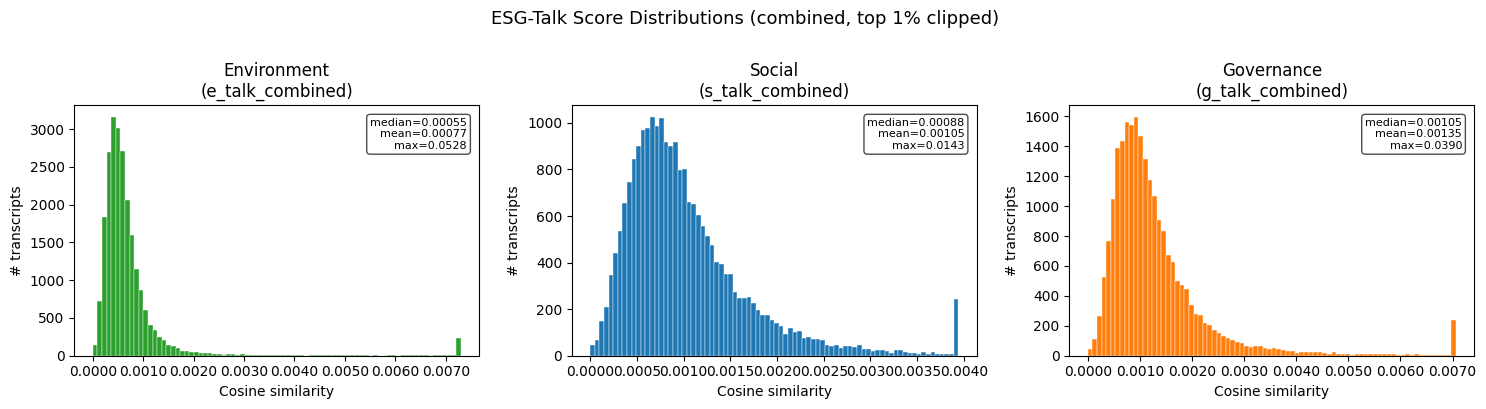

Saved → reports/figures/esg_talk_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, corp in zip(axes, CORPORA):
    col  = f"{corp}_talk_combined"
    vals = df[col]
    # clip top 1% for readability
    cap  = vals.quantile(0.99)
    ax.hist(vals.clip(upper=cap), bins=80, color=COLORS[corp],
            edgecolor="white", linewidth=0.3)
    ax.set_title(f"{CORPUS_LABELS[corp]}\n({col})", fontsize=12)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("# transcripts")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.text(0.97, 0.95, f"median={vals.median():.5f}\nmean={vals.mean():.5f}\nmax={vals.max():.4f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle("ESG-Talk Score Distributions (combined, top 1% clipped)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "esg_talk_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/esg_talk_distributions.png")

## Presentation vs. answers: score comparison

How much does ESG content differ between the prepared presentation and the Q&A answers?

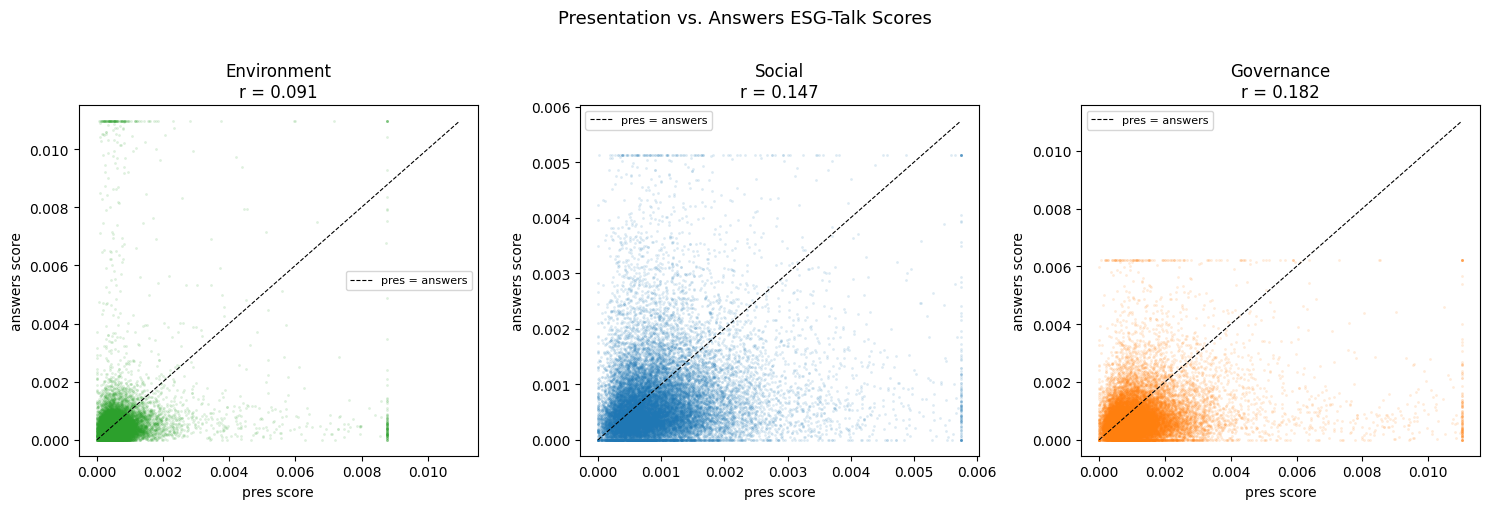

Saved → reports/figures/esg_talk_pres_vs_answers.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cap_q = 0.995   # clip both axes at 99.5th percentile for readability

for ax, corp in zip(axes, CORPORA):
    x = df[f"{corp}_talk_pres"]
    y = df[f"{corp}_talk_answers"]
    xc, yc = x.quantile(cap_q), y.quantile(cap_q)
    ax.scatter(x.clip(upper=xc), y.clip(upper=yc),
               alpha=0.15, s=4, color=COLORS[corp], linewidths=0)
    lim = max(xc, yc)
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="pres = answers")
    corr = x.corr(y)
    ax.set_title(f"{CORPUS_LABELS[corp]}\nr = {corr:.3f}", fontsize=12)
    ax.set_xlabel("pres score")
    ax.set_ylabel("answers score")
    ax.legend(fontsize=8)

fig.suptitle("Presentation vs. Answers ESG-Talk Scores", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "esg_talk_pres_vs_answers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/esg_talk_pres_vs_answers.png")

## Correlation matrix across all 9 scores

Pearson correlations between all combinations of E/S/G × combined/pres/answers.

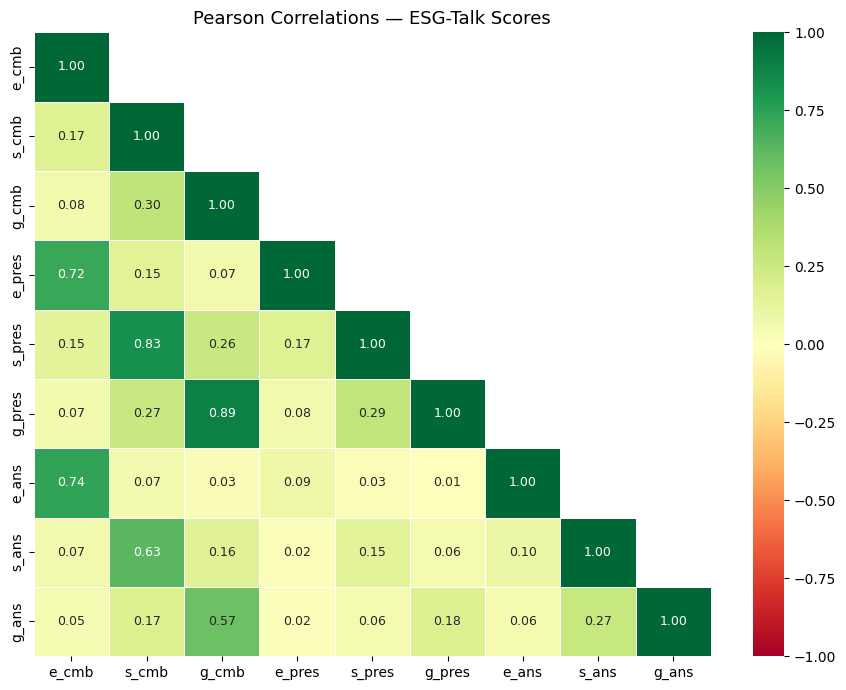

Saved → reports/figures/esg_talk_correlation.png
Saved → reports/tables/esg_talk_correlation.csv


In [9]:
corr = df[ALL_SCORE_COLS].corr()

# Shorten labels for display
short = {c: c.replace("_talk_combined", "_cmb")
              .replace("_talk_pres",     "_pres")
              .replace("_talk_answers",  "_ans")
         for c in ALL_SCORE_COLS}
corr_display = corr.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)
sns.heatmap(corr_display, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, mask=mask, ax=ax,
            linewidths=0.5, annot_kws={"size": 9})
ax.set_title("Pearson Correlations — ESG-Talk Scores", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "esg_talk_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Also save as table
corr.to_csv(TAB_DIR / "esg_talk_correlation.csv")
print("Saved → reports/figures/esg_talk_correlation.png")
print("Saved → reports/tables/esg_talk_correlation.csv")

## Time trend: mean ESG-talk scores by year

Average score per calendar year for each dimension (combined set).

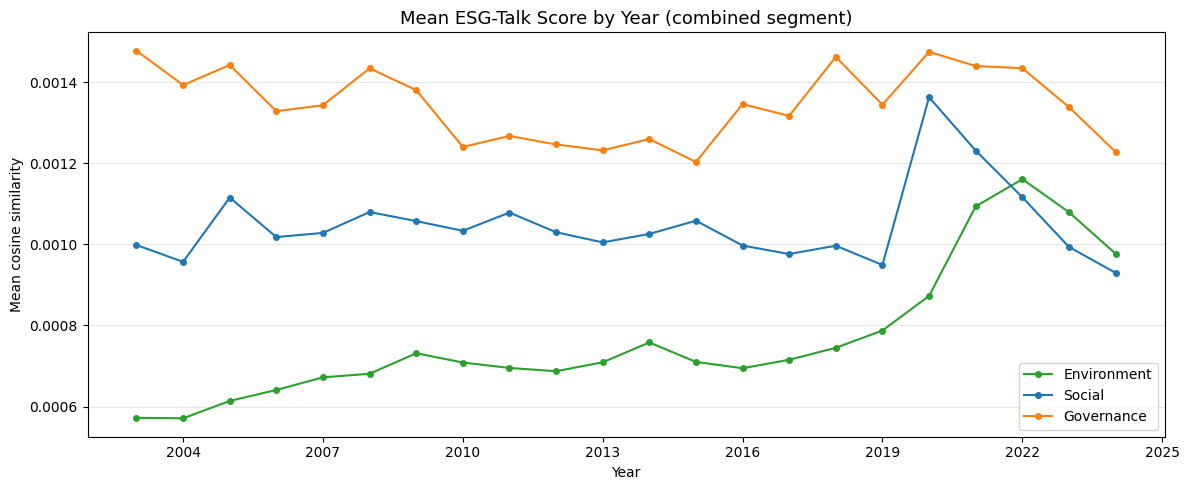

In [15]:
annual = (df.groupby("year_call")[SCORE_COLS["combined"]]
            .mean()
            .reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for corp in CORPORA:
    col = f"{corp}_talk_combined"
    ax.plot(annual["year_call"], annual[col],
            marker="o", markersize=4, label=CORPUS_LABELS[corp],
            color=COLORS[corp])

ax.set_title("Mean ESG-Talk Score by Year (combined segment)", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Mean cosine similarity")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "esg_talk_time_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary statistics table

Descriptive stats for all 9 scores, saved to `reports/tables/`.

In [13]:
stats = df[ALL_SCORE_COLS].describe().T
stats.index = stats.index.str.replace("_talk_", " | ").str.upper()
stats.to_csv(TAB_DIR / "esg_talk_summary_stats.csv")
print("Saved → reports/tables/esg_talk_summary_stats.csv\n")
display(stats.style.format("{:.6f}"))

Saved → reports/tables/esg_talk_summary_stats.csv



,count,mean,std,min,25%,50%,75%,max
E | COMBINED,23121.000000,0.000775,0.001284,0.000000,0.000376,0.000547,0.000784,0.052841
S | COMBINED,23121.000000,0.001050,0.000784,0.000000,0.000585,0.000876,0.001288,0.014257
G | COMBINED,23121.000000,0.001347,0.001381,0.000000,0.000718,0.001048,0.001537,0.039010
E | PRES,23121.000000,0.000664,0.001291,0.000000,0.000298,0.000468,0.000705,0.052325
S | PRES,23121.000000,0.001039,0.000923,0.000000,0.000515,0.000832,0.001285,0.017015
G | PRES,23121.000000,0.001327,0.001573,0.000000,0.000633,0.000998,0.001530,0.044860
E | ANSWERS,23121.000000,0.000551,0.001411,0.000000,0.000195,0.000356,0.000570,0.074336
S | ANSWERS,23121.000000,0.000762,0.000889,0.000000,0.000276,0.000537,0.000949,0.020453
G | ANSWERS,23121.000000,0.000851,0.001323,0.000000,0.000333,0.000619,0.001018,0.055161
